In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
# This prints every file and folder the script can see right now
print("I can see these items:", os.listdir())

I can see these items: ['amsterdam-weekdays-clean.ipynb', 'consolidated-data.ipynb', 'data']


In [3]:
# consolidating 20 data files
cities = ['amsterdam', 'athens', 'barcelona', 'berlin', 'budapest', 'lisbon', 
          'london', 'paris', 'rome', 'vienna']
types = ['weekdays', 'weekends']

all_dfs = []

for city in cities:
    for day in types:
        # Since 'data' is in the same folder as script:
        file_path = f"data/{city}_{day}.csv"
        
        try:
            df = pd.read_csv(file_path)
            df['city'] = city
            df['day_type'] = day
            all_dfs.append(df)
        except FileNotFoundError:
            print(f"Skipping: {file_path} (File not found)")

if all_dfs:
    master_df = pd.concat(all_dfs, ignore_index=True)
    print(f"Success! Created master_df with {master_df.shape[0]} rows.")
else:
    print("Zero files were loaded. Check your folder names again!")

Success! Created master_df with 51707 rows.


In [4]:
#checking all 20 files have merged correctly
master_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51707 entries, 0 to 51706
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  51707 non-null  int64  
 1   realSum                     51707 non-null  float64
 2   room_type                   51707 non-null  object 
 3   room_shared                 51707 non-null  bool   
 4   room_private                51707 non-null  bool   
 5   person_capacity             51707 non-null  float64
 6   host_is_superhost           51707 non-null  bool   
 7   multi                       51707 non-null  int64  
 8   biz                         51707 non-null  int64  
 9   cleanliness_rating          51707 non-null  float64
 10  guest_satisfaction_overall  51707 non-null  float64
 11  bedrooms                    51707 non-null  int64  
 12  dist                        51707 non-null  float64
 13  metro_dist                  517

In [5]:
#removing unnamed:0 column, lat, long, attr index, rest index, rest index norm, and attr index norm. If file already dropped, no error.
master_df = master_df.drop(columns=['Unnamed: 0', 'lat', 'lng', 'attr_index', 'rest_index', 'attr_index_norm', 'rest_index_norm'], errors='ignore')

#confirming drop
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51707 entries, 0 to 51706
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   realSum                     51707 non-null  float64
 1   room_type                   51707 non-null  object 
 2   room_shared                 51707 non-null  bool   
 3   room_private                51707 non-null  bool   
 4   person_capacity             51707 non-null  float64
 5   host_is_superhost           51707 non-null  bool   
 6   multi                       51707 non-null  int64  
 7   biz                         51707 non-null  int64  
 8   cleanliness_rating          51707 non-null  float64
 9   guest_satisfaction_overall  51707 non-null  float64
 10  bedrooms                    51707 non-null  int64  
 11  dist                        51707 non-null  float64
 12  metro_dist                  51707 non-null  float64
 13  city                        517

In [6]:
#renaming columns for clarity 
master_df = master_df.rename(columns={
    'realSum': 'total_booking_price',
    'dist': 'dist_city_center',
    'biz': 'is_business',
    'multi': 'multiple_listings'
})

#confirming name changes
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51707 entries, 0 to 51706
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   total_booking_price         51707 non-null  float64
 1   room_type                   51707 non-null  object 
 2   room_shared                 51707 non-null  bool   
 3   room_private                51707 non-null  bool   
 4   person_capacity             51707 non-null  float64
 5   host_is_superhost           51707 non-null  bool   
 6   multiple_listings           51707 non-null  int64  
 7   is_business                 51707 non-null  int64  
 8   cleanliness_rating          51707 non-null  float64
 9   guest_satisfaction_overall  51707 non-null  float64
 10  bedrooms                    51707 non-null  int64  
 11  dist_city_center            51707 non-null  float64
 12  metro_dist                  51707 non-null  float64
 13  city                        517

In [7]:
#finding missing values per column
master_df.isna().sum()

#printing percentage of null values
print("\n--- Percentage of Missing Data ---")
print((master_df.isnull().sum() / len(master_df)) * 100)



--- Percentage of Missing Data ---
total_booking_price           0.0
room_type                     0.0
room_shared                   0.0
room_private                  0.0
person_capacity               0.0
host_is_superhost             0.0
multiple_listings             0.0
is_business                   0.0
cleanliness_rating            0.0
guest_satisfaction_overall    0.0
bedrooms                      0.0
dist_city_center              0.0
metro_dist                    0.0
city                          0.0
day_type                      0.0
dtype: float64


In [9]:
#finding duplicated data
master_df.duplicated(keep=False).sum()

np.int64(0)

In [8]:
#checking min and max prices
master_df['total_booking_price'].describe()

count    51707.000000
mean       279.879591
std        327.948386
min         34.779339
25%        148.752174
50%        211.343089
75%        319.694287
max      18545.450285
Name: total_booking_price, dtype: float64

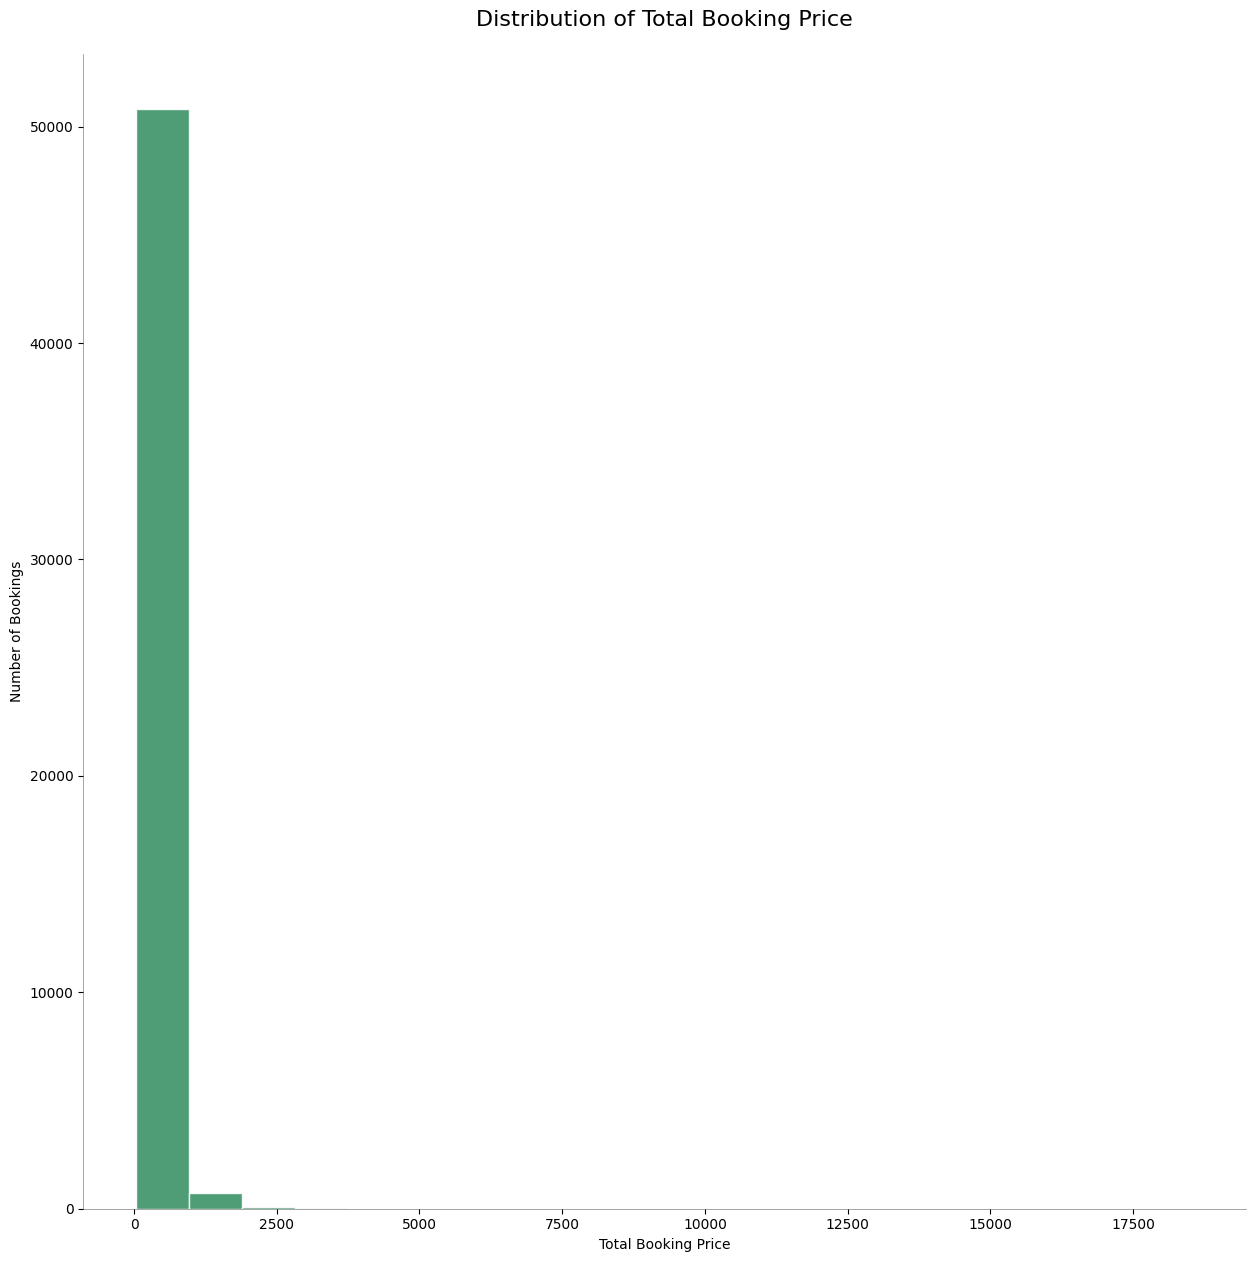

In [24]:
#checking distribution of total booking prices via histogram
plt.figure(figsize=(15,15))
plt.hist(
    master_df["total_booking_price"] , 
    bins=20,
    color = "#3b9268",
    alpha= 0.9, 
    edgecolor= "white"

)
plt.xlabel("Total Booking Price")
plt.ylabel("Number of Bookings")
plt.title("Distribution of Total Booking Price", fontsize=16, pad=20)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()


In [25]:
# grouping by city and calculating average total booking prices
avg_price = master_df.groupby('city')['total_booking_price'].mean().sort_values(ascending=False)
avg_price


city
amsterdam    573.112795
paris        392.531403
london       362.469256
barcelona    293.753706
berlin       244.583752
vienna       241.582484
lisbon       238.210479
rome         205.391950
budapest     176.513548
athens       151.744121
Name: total_booking_price, dtype: float64

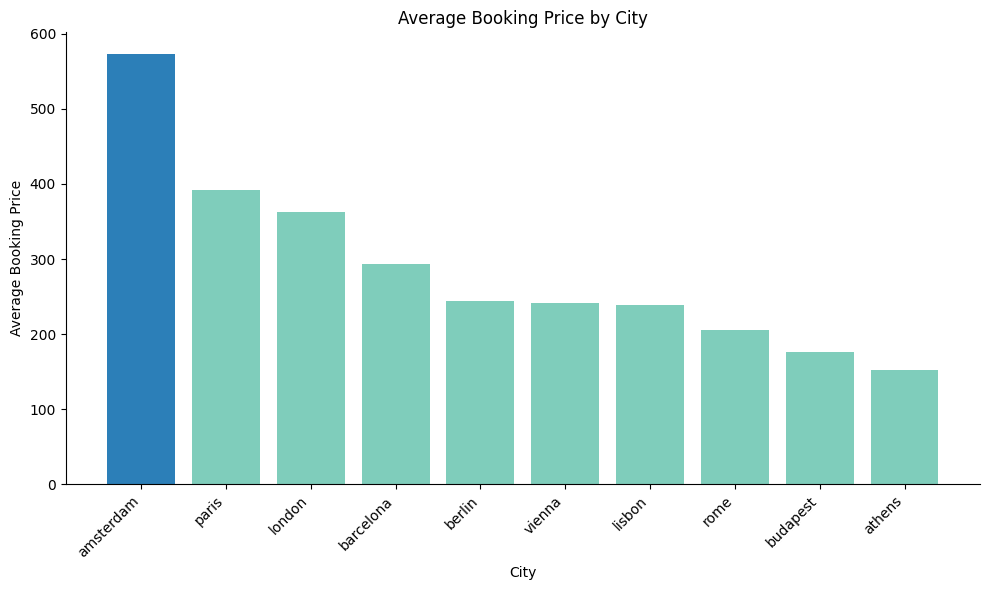

In [27]:
#comparing cities and average total booking prices
plt.figure(figsize=(10,6))
colors = ['#7fcdbb'] * len(avg_price)

max_index = avg_price.idxmax()
highlight_position = avg_price.index.get_loc(max_index)
colors[highlight_position] = "#2c7fb8"

plt.bar(avg_price.index, avg_price.values, color = colors, width = 0.8)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('City')
plt.ylabel('Average Booking Price')
plt.title('Average Booking Price by City')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()

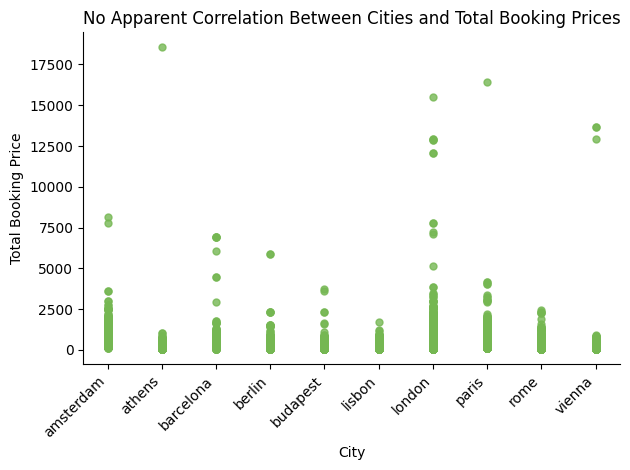

In [35]:
#exploring patterns between booking prices and cities
plt.scatter(master_df["city"], master_df["total_booking_price"], color = "#75b752",
    alpha = 0.8, 
    s = 25 )

plt.xlabel("City")
plt.ylabel("Total Booking Price")
plt.title("No Apparent Correlation Between Cities and Total Booking Prices")
plt.xticks(rotation=45, ha='right')

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [13]:
#multivariate analyis by reducing dataframe to quantitative variables only and displaying correlation matrix
master_df.columns
numerical_df=master_df[['total_booking_price','person_capacity', 'multiple_listings',
       'is_business', 'cleanliness_rating', 'guest_satisfaction_overall',
       'bedrooms', 'dist_city_center', 'metro_dist' ]]

numerical_df.head()

,total_booking_price,person_capacity,multiple_listings,is_business,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist_city_center,metro_dist
0,194.033698,2.0,1,0,10.0,93.0,1,5.022964,2.539380
1,344.245776,4.0,0,0,8.0,85.0,1,0.488389,0.239404
2,264.101422,2.0,0,1,9.0,87.0,1,5.748312,3.651621
3,433.529398,4.0,0,1,9.0,90.0,2,0.384862,0.439876
4,485.552926,2.0,0,0,10.0,98.0,1,0.544738,0.318693


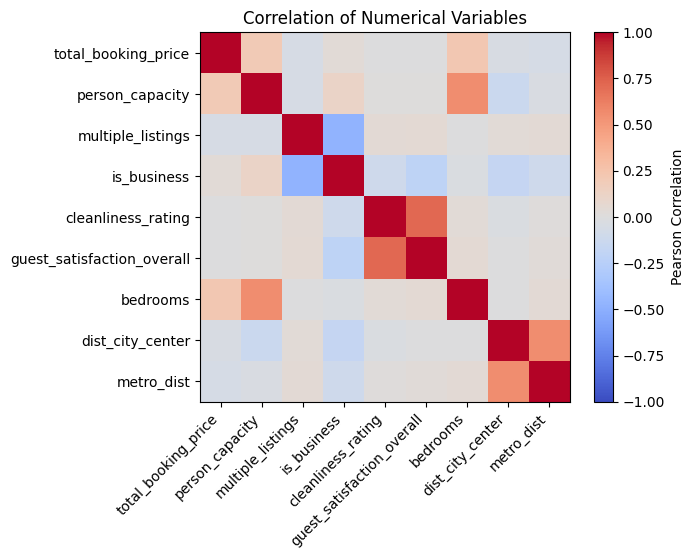

In [15]:
#creating a heatmap
corr = numerical_df.corr()

im = plt.imshow(corr, vmin=-1, cmap="coolwarm")
plt.colorbar(im, label= "Pearson Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation of Numerical Variables")

plt.show()